In [2]:
import pandas as pd

In [40]:
df=pd.read_csv('synthetic_credit_data_v2.csv')
df.head()

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0


In [41]:
# Make a Copy
df_model=df.copy()

In [42]:
# Dropping borrower ID
df_model.drop('borrower_id',
              axis=1,
              inplace=True)

In [43]:
df_model.columns

Index(['age', 'occupation', 'monthly_income', 'income_consistency_score',
       'utility_delay_days', 'debt_to_income_ratio', 'active_loans',
       'upi_transactions', 'previous_default', 'loan_status'],
      dtype='object')

In [44]:
# Algorithm needs numbers ,not texts
# Converting texts to numbers
df_model=pd.get_dummies(
    df_model,
    columns=['occupation'],
    drop_first=True)

In [45]:
# Features and Target
X=df_model.drop('loan_status',axis=1)
Y=df_model['loan_status']

In [46]:
X.shape

(10000, 12)

In [47]:
Y.shape

(10000,)

In [48]:
# Train,Test and Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.20,random_state=42,stratify=Y)

In [49]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
modelA=LogisticRegression(
    max_iter=1000,
    random_state=42)
modelA.fit(X_train,Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [50]:
prediction=modelA.predict(X_test)
prediction

array([1, 1, 0, ..., 1, 1, 1])

In [51]:
probability=modelA.predict_proba(X_test)[:,1]
probability

array([0.92712422, 0.95240281, 0.12131052, ..., 0.93601062, 0.75048652,
       0.8120222 ])

In [57]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(Y_test,prediction)
accuracy

0.9075

In [53]:
from sklearn.metrics import classification_report
classification_report(Y_test,prediction)

'              precision    recall  f1-score   support\n\n           0       0.87      0.66      0.75       429\n           1       0.91      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.82      0.85      2000\nweighted avg       0.91      0.91      0.90      2000\n'

In [54]:
# True Positive(tp)-Good borrower approved
# True Negative(tn)-Bad borrower rejected
# False Positive(fp)-Bad borrower approved
# False Negative(fn)-Good borrower rejected
# Confusion Matrix=[tn  fp
                   #tp  tp]
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,prediction)
cm

array([[ 285,  144],
       [  41, 1530]])

In [55]:
from sklearn.metrics import roc_auc_score
auc=roc_auc_score(Y_test,prediction)
auc

0.8191188188005502

In [58]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [59]:
dt=DecisionTreeClassifier(
    random_state=42,
    max_depth=5)

In [60]:
dt.fit(X_train,Y_train)
prediction=dt.predict(X_test)
prediction

array([1, 1, 0, ..., 1, 1, 1])

In [61]:
probability=dt.predict_proba(X_test)[:,1]
probability

array([0.87876106, 0.94246709, 0.11711712, ..., 0.94905213, 0.90679305,
       0.94246709])

In [62]:
score=accuracy_score(Y_test,prediction)
score

0.9055

In [63]:
classification_report(Y_test,prediction)

'              precision    recall  f1-score   support\n\n           0       0.86      0.67      0.75       429\n           1       0.91      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.82      0.85      2000\nweighted avg       0.90      0.91      0.90      2000\n'

In [64]:
confusion_matrix(Y_test,prediction)

array([[ 286,  143],
       [  46, 1525]])

In [65]:
roc_auc_score(Y_test,prediction)

0.8186929768724804

In [67]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [69]:
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10)

In [70]:
rf.fit(X_train,Y_train)
prediction=rf.predict(X_test)
prediction

array([1, 1, 0, ..., 1, 1, 1])

In [71]:
accuracy_score(Y_test, prediction)

0.9085

In [72]:
classification_report(Y_test, prediction)

'              precision    recall  f1-score   support\n\n           0       0.86      0.69      0.76       429\n           1       0.92      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.83      0.85      2000\nweighted avg       0.91      0.91      0.90      2000\n'

In [73]:
confusion_matrix(Y_test, prediction)

array([[ 294,  135],
       [  48, 1523]])

In [74]:
roc_auc_score(Y_test,prediction)

0.8273804489590613

In [75]:
# Finally we decided to continue with Random Forest
# Reason
# It catches more risky borrowers

In [85]:
# Repayment Probabilities
repayment_prob = rf.predict_proba(X)[:, 1]
df['repayment_prob']=repayment_prob


In [86]:
# Convert Probability to Credit Score
# 300-highest risk
# 900-lowest risk
df["percentile"] = (
    df["repayment_prob"]
      .rank(pct=True)
)

df["credit_score"] = (
    300 + df["percentile"]*600
).astype(int)

In [87]:
# Adding Credit score to data sheet
df['credit_score']=credit_score
df

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status,credit_score,risk_category,loan_decision,repayment_prob,percentile
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1,860,Excellent,Approve,0.934878,0.6466
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1,882,Excellent,Approve,0.971615,0.9760
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1,880,Excellent,Approve,0.967704,0.9597
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1,878,Excellent,Approve,0.963392,0.9291
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0,333,High Risk,Reject,0.056151,0.0312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BORR09996,36,Driver,25901.21,78,1,0.252,0,156,0,1,850,Excellent,Approve,0.917841,0.4757
9996,BORR09997,43,Small Business Owner,63210.83,81,0,0.257,0,244,1,1,886,Excellent,Approve,0.978079,0.9944
9997,BORR09998,59,Freelancer,45634.18,76,0,0.225,0,149,0,1,868,Excellent,Approve,0.948190,0.7886
9998,BORR09999,29,Delivery Partner,24100.07,72,1,0.208,0,157,0,1,844,Excellent,Approve,0.907369,0.3982


In [88]:
# Creating risk category
def risk_category(score):
    if score >= 800:
        return "Excellent"
    elif score >= 650:
        return "Low Risk"
    elif score >= 500:
        return "Moderate Risk"
    else:
        return "High Risk"
        
df['risk_category']=(df['credit_score'].apply(risk_category)) 
df

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status,credit_score,risk_category,loan_decision,repayment_prob,percentile
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1,860,Excellent,Approve,0.934878,0.6466
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1,882,Excellent,Approve,0.971615,0.9760
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1,880,Excellent,Approve,0.967704,0.9597
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1,878,Excellent,Approve,0.963392,0.9291
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0,333,High Risk,Reject,0.056151,0.0312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BORR09996,36,Driver,25901.21,78,1,0.252,0,156,0,1,850,Excellent,Approve,0.917841,0.4757
9996,BORR09997,43,Small Business Owner,63210.83,81,0,0.257,0,244,1,1,886,Excellent,Approve,0.978079,0.9944
9997,BORR09998,59,Freelancer,45634.18,76,0,0.225,0,149,0,1,868,Excellent,Approve,0.948190,0.7886
9998,BORR09999,29,Delivery Partner,24100.07,72,1,0.208,0,157,0,1,844,Excellent,Approve,0.907369,0.3982


In [89]:
# Loan Recommendation 
def recommendation(score):
    if score >= 750:
        return "Approve"
    elif score >= 650:
        return "Approve with Monitoring"
    elif score >= 500:
        return "Manual Review"
    return "Reject"

df["loan_decision"] = (
    df["credit_score"]
    .apply(recommendation)
)   
df

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status,credit_score,risk_category,loan_decision,repayment_prob,percentile
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1,860,Excellent,Approve,0.934878,0.6466
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1,882,Excellent,Approve,0.971615,0.9760
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1,880,Excellent,Approve,0.967704,0.9597
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1,878,Excellent,Approve,0.963392,0.9291
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0,333,High Risk,Reject,0.056151,0.0312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BORR09996,36,Driver,25901.21,78,1,0.252,0,156,0,1,850,Excellent,Approve,0.917841,0.4757
9996,BORR09997,43,Small Business Owner,63210.83,81,0,0.257,0,244,1,1,886,Excellent,Approve,0.978079,0.9944
9997,BORR09998,59,Freelancer,45634.18,76,0,0.225,0,149,0,1,868,Excellent,Approve,0.948190,0.7886
9998,BORR09999,29,Delivery Partner,24100.07,72,1,0.208,0,157,0,1,844,Excellent,Approve,0.907369,0.3982


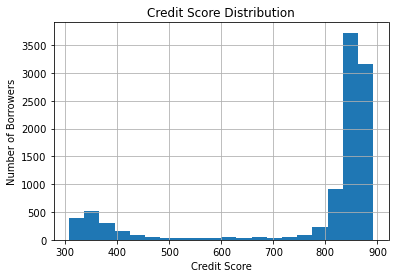

In [91]:
# Representation of credit score
import matplotlib.pyplot as plt
df["credit_score"].hist(bins=20)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Borrowers")
plt.show()

In [92]:
# Importance or Contribution of different features
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_})
importance = importance.sort_values(
    by="Importance",
    ascending=False)
importance

,Feature,Importance
4,debt_to_income_ratio,0.321957
3,utility_delay_days,0.208914
2,income_consistency_score,0.175073
6,upi_transactions,0.108351
5,active_loans,0.070143
1,monthly_income,0.048424
0,age,0.029272
7,previous_default,0.023046
11,occupation_Small Business Owner,0.004099
8,occupation_Driver,0.003913


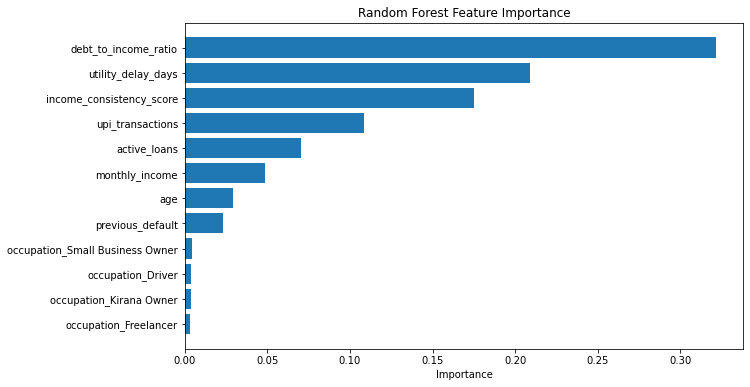

In [93]:
# Visual representation
plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()